# Implementation !

Since we can't train a transformer over text here, simply because it would require huge datasets and computation resources, let's try some easier case that tries to mimick what happens in text.
Let's suppose a vocabulary consists of only three words, or tokens : a quare, a circle, and a cross $ \Omega = \{ X, O, \Box \}$

Now we must naturally introduce some rules for this language, let them be the following : 
- we can rither repeate one token, in this sentence no other word must intrefere : Ex : "X X X X X X"
- we can either have doubling sequence, repeating only two tokens : Ex : " X O X O X O"
- and finally, a circular rotation of all three tokens : " X O sq X O sq X O sq "

In [ ]:

# ── Imports ─────────────────────────────────────────────────────────────────
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D



In [4]:
torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
# ── Vocabulary ───────────────────────────────────────────────────────────────
# x=0  o=1  sq=2
VOCAB      = {"x ": 0, "o ": 1, "sq": 2}
VOCAB_SIZE = len(VOCAB)
IDX2TOK    = {v: k for k, v in VOCAB.items()}
X, O, SQ   = 0, 1, 2

In [6]:
# ── Pattern generators ───────────────────────────────────────────────────────
def pattern_repeat(token, length=13):
    """x x x x x x"""
    return [token] * length

def pattern_cycle3(length=13):
    """x o sq x o sq ..."""
    base = rotate_list_random([X, O, SQ])
    return (base * (length // 3 + 1))[:length]

def pattern_alternate1(length=13):
    """x o x o x o ..."""
    base = rotate_list_random([X, O])
    return (base * (length // 2 + 1))[:length]

def pattern_alternate2(length=13):
    """x o x o x o ..."""
    base = rotate_list_random([X, SQ])
    return (base * (length // 2 + 1))[:length]

def rotate_list_random(a):
    n = np.random.randint(0, 3)
    if n == 0 : return a
    return (a[-n:] + a[:-n])


PATTERNS = [
    lambda: pattern_repeat(X),
    lambda: pattern_repeat(O),
    lambda: pattern_repeat(SQ),
    pattern_cycle3,
    pattern_alternate1,
    pattern_alternate2,
]


In [7]:
# ── Dataset ──────────────────────────────────────────────────────────────────
class SequenceDataset(Dataset):
    def __init__(self, n_samples=600, seq_len=13):
        self.seq_len = seq_len
        self.data    = []
        for _ in range(n_samples):
            fn  = PATTERNS[np.random.randint(len(PATTERNS))]
            seq = fn()
            # input = seq[:-1], target = seq[1:]  (autoregressive)
            self.data.append((
                torch.tensor(seq[:-1], dtype=torch.long),
                torch.tensor(seq[1:],  dtype=torch.long),
            ))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [8]:

# ── Visualisation helpers ─────────────────────────────────────────────────────
COLORS  = {"x": "#E05A5A", "o": "#5A9BE0", "sq": "#5AC476"}
MARKERS = {"x": "X",       "o": "o",       "sq": "s"}

def plot_loss(history):
    plt.figure(figsize=(7, 3))
    plt.plot(history, linewidth=2, color="#5A9BE0")
    plt.xlabel("Epoch"); plt.ylabel("Cross-entropy loss")
    plt.title("Training loss"); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_static_embeddings(model):
    """Plot the raw token embedding table — before context."""
    W   = model.token_emb.weight.detach().cpu().numpy()[:3]   # x, o, sq
    pca = PCA(n_components=2).fit_transform(W)

    fig, ax = plt.subplots(figsize=(5, 5))
    for i, tok in enumerate(["x", "o", "sq"]):
        ax.scatter(*pca[i], s=300, color=COLORS[tok],
                   marker=MARKERS[tok], zorder=3, label=tok)
        ax.annotate(tok, pca[i], textcoords="offset points",
                    xytext=(8, 4), fontsize=12)
    ax.set_title("Static token embeddings (before attention)")
    ax.legend(); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()


def plot_contextual_embeddings(model):
    """
    Extract the contextual embedding of token X across all pattern contexts.
    Same input token → different output vector depending on pattern.
    This is the 'avocado moment'.
    """
    model.eval()

    # One representative sequence per pattern (length 11 = seq_len)
    test_seqs = {
        "repeat-x":      pattern_repeat(X)[:-1],
        "cycle-3":       pattern_cycle3()[:-1],
    }

    all_vecs, all_labels, all_tokens = [], [], []

    with torch.no_grad():
        for pattern_name, seq in test_seqs.items():
            t      = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)
            hidden = model.get_contextual_embeddings(t)[0]   # (T, D)

            for pos, tok_id in enumerate(seq):
                tok_name = IDX2TOK[tok_id]
                all_vecs.append(hidden[pos].cpu().numpy())
                all_labels.append(pattern_name)
                all_tokens.append(tok_name)

    vecs = np.array(all_vecs)
    pca  = PCA(n_components=2).fit_transform(vecs)

    # ── Plot: colour = pattern, shape = token ────────────────────────────────
    pattern_colors = {
        "repeat-x":      "#E05A5A",
        "cycle-3":       "#5A9BE0",
        "alternating":   "#5AC476",
    }

    fig, ax = plt.subplots(figsize=(8, 6))
    for i, (label, tok) in enumerate(zip(all_labels, all_tokens)):
        ax.scatter(
            pca[i, 0], pca[i, 1],
            color=pattern_colors[label],
            marker=MARKERS[tok],
            s=120, alpha=0.8,
        )

    # Legend: patterns
    pat_patches = [
        mpatches.Patch(color=c, label=p)
        for p, c in pattern_colors.items()
    ]
    # Legend: tokens
    tok_handles = [
        plt.scatter([], [], marker=MARKERS[t], color="gray", s=80, label=t)
        for t in ["x", "o", "sq"]
    ]
    ax.legend(handles=pat_patches + tok_handles,
              loc="upper right", fontsize=9, framealpha=0.8)
    ax.set_title("Contextual embeddings — same token, different context\n"
                 "(colour = pattern, shape = token)")
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


def plot_attention_maps(model):
    """
    Plot attention weights for each pattern.
    Uses the first head of the first layer.
    """
    model.eval()

    test_seqs = {
        "repeat-x":      pattern_repeat(X)[:-1],
        "cycle-3":       pattern_cycle3()[:-1]
    }

    # Register a hook on the first attention layer
    attention_weights = {}

    def hook_fn(module, input, output):
        # output[1] = attention weights when need_weights=True
        if isinstance(output, tuple) and output[1] is not None:
            attention_weights["attn"] = output[1].detach().cpu()

    # Hook into the self-attention of the first encoder layer
    handle = model.transformer.layers[0].self_attn.register_forward_hook(hook_fn)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    with torch.no_grad():
        for ax, (name, seq) in zip(axes, test_seqs.items()):
            t = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)

            # need_weights must be True — patch the layer temporarily
            model.transformer.layers[0].self_attn.need_weights = True
            model(t)

            if "attn" in attention_weights:
                # shape: (B, heads, T, T) or (B, T, T) depending on version
                w = attention_weights["attn"]
                if w.dim() == 4:
                    w = w[0, 0]   # first batch, first head
                else:
                    w = w[0]

                tok_labels = [IDX2TOK[i] for i in seq]
                im = ax.imshow(w.numpy(), cmap="Blues", vmin=0, vmax=1)
                ax.set_xticks(range(len(seq))); ax.set_xticklabels(tok_labels, fontsize=8)
                ax.set_yticks(range(len(seq))); ax.set_yticklabels(tok_labels, fontsize=8)
                ax.set_title(name, fontsize=10)
                plt.colorbar(im, ax=ax, fraction=0.046)
            attention_weights.clear()

    handle.remove()
    plt.suptitle("Attention maps — head 0, layer 0", fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()


# ── Generation ────────────────────────────────────────────────────────────────
def generate(model, prompt: list, n_new: int = 6) -> list:
    """Autoregressively generate n_new tokens given a prompt."""
    model.eval()
    seq = prompt[:]
    with torch.no_grad():
        for _ in range(n_new):
            t      = torch.tensor(seq[-model.seq_len:],
                                  dtype=torch.long).unsqueeze(0).to(device)
            logits, _ = model(t)
            next_tok  = logits[0, -1].argmax().item()
            seq.append(next_tok)
    
    return seq

def return_probs(model, prompt):
    """ return the probability of the next-token over the set of tokens"""
    model.eval()
    t = torch.tensor(prompt[-model.seq_len:],
                                  dtype=torch.long).unsqueeze(0).to(device)
    logits,_ = model(t)
    # return F.softmax(logits, dim=0)
    return F.softmax(logits[0, -1], dim=-1).tolist()


In [196]:
# ── Transformer ──────────────────────────────────────────────────────────────
class TinyTransformer(nn.Module):
    """
    Small causal transformer for sequence modelling.

    Args:
        vocab_size  (int): Number of tokens.
        embed_dim   (int): Embedding dimensionality.
        n_heads     (int): Number of attention heads.
        n_layers    (int): Number of transformer blocks.
        seq_len     (int): Maximum sequence length.
        dropout     (float): Dropout probability.
    """
    def __init__(
        self,
        vocab_size: int = VOCAB_SIZE,
        embed_dim:  int = 32,
        n_heads:    int = 4,
        n_layers:   int = 3,
        seq_len:    int = 17,
        dropout:    float = 0.1,
    ):
        super().__init__()
        self.embed_dim = embed_dim
        self.seq_len   = seq_len

        # ── Token + positional embeddings ────────────────────────────────────
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        self.pos_emb   = nn.Embedding(seq_len,    embed_dim)

        # ── Transformer encoder layers (causal mask applied at forward) ──────
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=64, dropout=dropout,
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # ── Output projection ────────────────────────────────────────────────
        self.head = nn.Linear(embed_dim, vocab_size)

    def _causal_mask(self, size: int) -> torch.Tensor:
        """Upper-triangular mask to prevent attending to future tokens."""
        return torch.triu(torch.ones(size, size, device=device), diagonal=1).bool()

    def forward(self, x: torch.Tensor):
        B, T    = x.shape
        pos     = torch.arange(T, device=device).unsqueeze(0)           # (1, T)
        emb     = self.token_emb(x) + self.pos_emb(pos)                 # (B, T, D)
        mask    = self._causal_mask(T)
        out     = self.transformer(emb, mask=mask)                      # (B, T, D)
        logits  = self.head(out)                                        # (B, T, V)
        return logits, out   # return hidden states for embedding analysis

    def get_contextual_embeddings(self, x: torch.Tensor):
        """Return hidden states (contextual embeddings) without logits."""
        _, hidden = self.forward(x)
        return hidden
    
    def get_all_layer_outputs(self, x):
        """
        Return hidden states at every layer:
            layer 0 = raw token+positional embedding (before any attention)
            layer k = output of transformer block k
        """
        B, T   = x.shape
        pos    = torch.arange(T).unsqueeze(0)
        h      = self.token_emb(x) + self.pos_emb(pos)
        mask   = self._causal_mask(T)
 
        all_layers = [h.detach().cpu().numpy()]   # layer 0: static
 
        for layer in self.transformer.layers:
            h = layer(h, src_mask=mask)
            all_layers.append(h.detach().cpu().numpy())
 
        return all_layers   # list of (B, T, D) arrays, length = n_layers+1

    def get_all_layer_last_emb(self, x):
        """
        Return hidden state at every layer:
        """
        B, T   = x.shape
        pos    = torch.arange(T).unsqueeze(0)
        h      = self.token_emb(x) + self.pos_emb(pos)
        mask   = self._causal_mask(T)
 
        all_layers = [self.token_emb(x).detach().cpu().numpy()[-1][-1]]   # layer 0: static
 
        for layer in self.transformer.layers:
            h = layer(h, src_mask=mask)
            all_layers.append(h.detach().cpu().numpy()[-1][-1])
 
        return all_layers   # list of (B, T, D) arrays, length = n_layers+1

In [25]:
print(torch.arange(10, device=device).unsqueeze(0))

tensor([[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]])


In [10]:
def train(model, loader, epochs=100, lr=3e-3, ckpt_dir="checkpoints"):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history   = []
    os.makedirs(ckpt_dir, exist_ok=True)          # ← create folder once

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits, _ = model(x)
            loss = F.cross_entropy(
                logits.reshape(-1, VOCAB_SIZE),
                y.reshape(-1),
            )
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        history.append(avg)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | Loss: {avg:.4f}")

            # ── Save checkpoint every 5 epochs ──────────────────────────────
            ckpt_path = os.path.join(ckpt_dir, f"ckpt_epoch{epoch+1}.pt")
            torch.save(
                {
                    "epoch":           epoch + 1,
                    "model_state":     model.state_dict(),
                    "optimizer_state": optimizer.state_dict(),
                    "loss":            avg,
                },
                ckpt_path,
            )
            print(f"  ✔ Checkpoint saved → {ckpt_path}")

    return history

In [8]:
# ── Data ─────────────────────────────────────────────────────────────────
dataset    = SequenceDataset(n_samples=600, seq_len=13)
loader     = DataLoader(dataset, batch_size=128, shuffle=True)

# ── Model ────────────────────────────────────────────────────────────────
model = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=32,
    n_heads=4,
    n_layers=3,
    seq_len=12,
).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")



Parameters: 26,211


In [ ]:
# ── Train ─────────────────────────────────────────
# history = train(model, loader, epochs=200, lr=1e-3)

Epoch  20/100 | Loss: 0.1155
  ✔ Checkpoint saved → checkpoints\ckpt_epoch20.pt
Epoch  40/100 | Loss: 0.1009
  ✔ Checkpoint saved → checkpoints\ckpt_epoch40.pt
Epoch  60/100 | Loss: 0.0972
  ✔ Checkpoint saved → checkpoints\ckpt_epoch60.pt
Epoch  80/100 | Loss: 0.0983
  ✔ Checkpoint saved → checkpoints\ckpt_epoch80.pt
Epoch 100/100 | Loss: 0.0955
  ✔ Checkpoint saved → checkpoints\ckpt_epoch100.pt


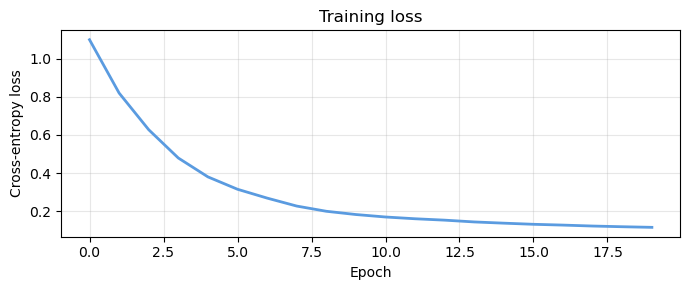

[1.0987919092178344, 0.819215965270996, 0.6270923018455505, 0.4788642704486847, 0.3799205541610718, 0.3150486290454865, 0.2687839537858963, 0.22703781425952912, 0.1997065156698227, 0.1826237380504608]
[0.09611787050962448, 0.09645723849534989, 0.09664782881736755, 0.09586022198200225, 0.09537186622619628, 0.09684080481529236, 0.09521899670362473, 0.09466219544410706, 0.09622052460908889, 0.09548272639513015]


In [84]:
plot_loss(history[:20])
print(history[:10])
print(history[-10:])

--------
# Validation

In [200]:
model = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=32,
    n_heads=4,
    n_layers=3,
    seq_len=12,
).to(device)

checkpoint = torch.load("checkpoints\ckpt_epoch100.pt", weights_only=True)
model.load_state_dict(checkpoint["model_state"])
loss = checkpoint["loss"]

In [17]:
model_untrained = TinyTransformer(
    vocab_size=VOCAB_SIZE,
    embed_dim=32,
    n_heads=4,
    n_layers=3,
    seq_len=12,
).to(device)

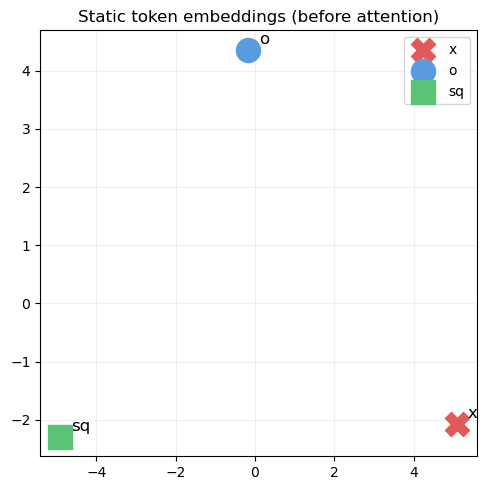

KeyError: 'x '

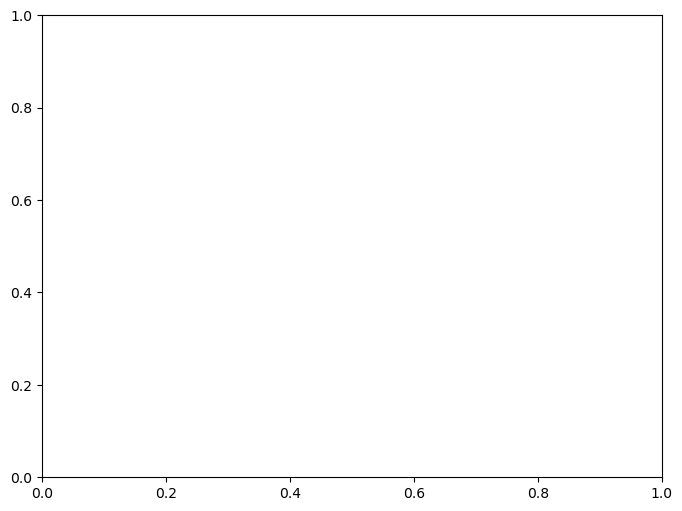

In [10]:
# plot_loss(loss)
plot_static_embeddings(model)
plot_contextual_embeddings(model)
plot_attention_maps(model)

In [13]:
# ── Generation demo ──────────────────────────────────────────────────────
print("\n── Pattern Completion ──────────────────────────────────────")
print("pattern → completion")
prompts = {
        "x  x  x  "*4      :       [X ,X ,X ]*4,
        "x  o  sq "*4      :       [X ,O ,SQ]*4,
        "x  o  "*6      :       [X ,O]*6,
        "sq o  x  "*4      :       [SQ,O ,X ]*4,
}
for desc, prompt in prompts.items():
    result = generate(model, prompt, n_new=6)
    result = result[12:]
    readable = " ".join(IDX2TOK[t] for t in result)
    print(f"{desc:45s} → {readable}")


── Pattern Completion ──────────────────────────────────────
pattern → completion
x  x  x  x  x  x  x  x  x  x  x  x            → x  x  x  x  x  x 
x  o  sq x  o  sq x  o  sq x  o  sq           → x  o  sq x  o  sq
x  o  x  o  x  o  x  o  x  o  x  o            → x  o  x  o  x  o 
sq o  x  sq o  x  sq o  x  sq o  x            → o  sq x  o  sq x 


In [14]:
def nums_to_tokens(nums):
    mapping = {0: "X", 1: "O", 2: "SQ"}
    return " ".join(mapping[n] for n in nums)

# Example
data = [0, 1, 2, 0, 0]
result = nums_to_tokens(data)
print(result)  # X O SQ X X

X O SQ X X


In [ ]:
patterns = {
    "repeat-x" : [X,X,X]*4,
            "repeat-o" : [O,O,O]*4,
            "alternate-x/o" : [X,O]*6,
            "cycle" : [SQ,X,O]*4}

trained   = []
untrained = []
description  = []
for pattern,prompt in patterns.items():
    trained.append(return_probs(model,prompt))
    untrained.append(return_probs(model_untrained,prompt))
    description.append(nums_to_tokens(prompt))

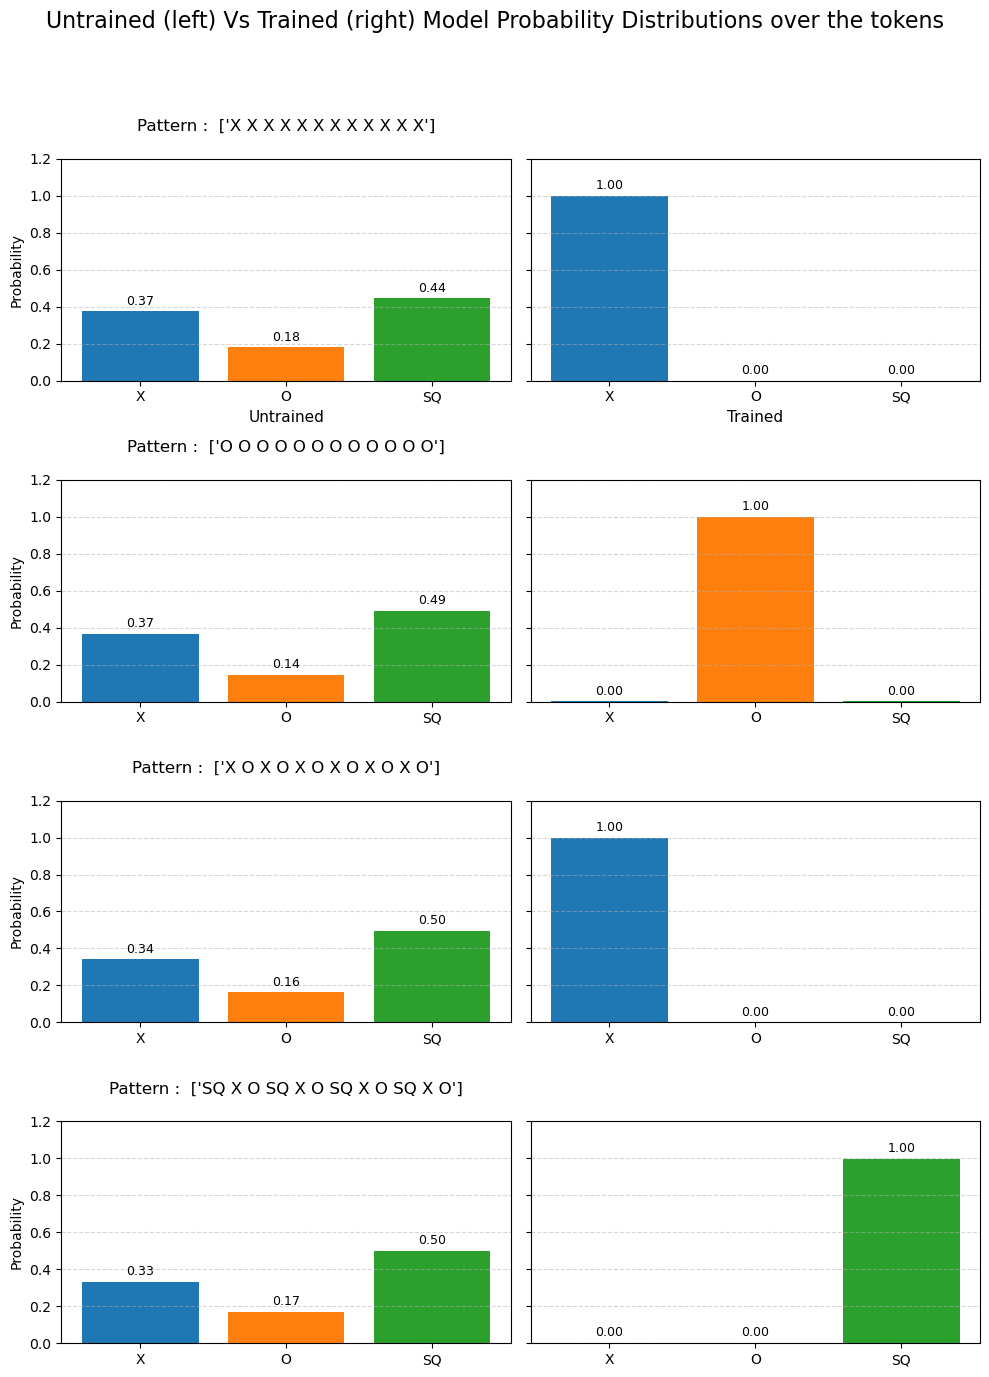

In [19]:
import matplotlib.pyplot as plt

tokens = ["X", "O", "SQ"]

# Assign a color per token (consistent everywhere)
colors = {
    "X": "tab:blue",
    "O": "tab:orange",
    "SQ": "tab:green"
}

fig, axes = plt.subplots(4, 2, figsize=(10, 14), sharey='row')

for i in range(4):
    ax_left = axes[i, 0]
    ax_right = axes[i, 1]

    probs_u = untrained[i]
    probs_t = trained[i]

    # Untrained (left)
    bars_u = ax_left.bar(tokens, probs_u,color=[colors[t] for t in tokens])
    for bar, p in zip(bars_u, probs_u):
        ax_left.text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.02,
                     f"{p:.2f}",
                     ha='center', va='bottom', fontsize=9)

    ax_left.set_ylim(0, 1.2)
    ax_left.set_ylabel("Probability")
    ax_left.set_title(f"Pattern :  {[description[i]]}", fontsize=12, pad=20)
    ax_left.grid(axis='y', linestyle='--', alpha=0.5)

    # Trained (right)
    bars_t = ax_right.bar(tokens, probs_t,color=[colors[t] for t in tokens])
    for bar, p in zip(bars_t, probs_t):
        ax_right.text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 0.02,
                      f"{p:.2f}",
                      ha='center', va='bottom', fontsize=9)

    ax_right.set_title("")  # remove per-plot title
    ax_right.grid(axis='y', linestyle='--', alpha=0.5)

    # Column headers only on first row
    if i == 0:
        ax_left.set_xlabel("Untrained", fontsize=11)
        ax_right.set_xlabel("Trained", fontsize=11)


fig.suptitle("Untrained (left) Vs Trained (right) Model Probability Distributions over the tokens", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space for legend

plt.show()

In [96]:
X_PATTERN_SEQS = {
    "repeat-x" : [X,X,X]*4,
    "alternate-x/o" : [O,X]*6,
    "alternate-x/sq" : [SQ,X]*6,
    "cycle-x-last" : [O,SQ,X]*4
}

O_PATTERN_SEQS = {
    "repeat-o" : [O,O,O]*4,
    "alternate-o/x" : [X,O]*6,
    "alternate-o/sq" : [SQ,O]*6,
    "cycle-o-last" : [SQ,X,O]*4
}

SQ_PATTERN_SEQS = {
    "repeat-sq" : [SQ,SQ,SQ]*4,
    "alternate-sq/x" : [X,SQ]*6,
    "alternate-sq/o" : [O,SQ]*6,
    "cycle-sq-last" : [X,O,SQ]*4
}

# let's concatenate all dicts
ALL_PATTERN_SEQS = (X_PATTERN_SEQS | O_PATTERN_SEQS | SQ_PATTERN_SEQS)
 
PATTERN_COLORS = {
    "repeat-X":      "#E05A5A",
    "cycle-3":       "#5A9BE0",
    "alternate":     "#5AC476",
    "reverse-cycle": "#E0A85A",
}

# Gather all hidden states
pattern_layers = {}
with torch.no_grad():
    for name, seq in ALL_PATTERN_SEQS.items():
        t = torch.tensor(seq, dtype=torch.long).unsqueeze(0)
        layers = model.get_all_layer_outputs(t)   # list of (1,T,D)
        pattern_layers[name] = [l[0] for l in layers]   # list of (T,D)

n_layers = len(list(pattern_layers.values()))   # should be 3 (emb + 2 layers)


In [98]:
# ── Fit PCA on ALL vectors across all patterns and all layers ─────────────────
all_vecs = np.concatenate([
    np.concatenate(layers, axis=0)
    for layers in pattern_layers.values()
], axis=0)
 
pca = PCA(n_components=3)
pca.fit(all_vecs)
 
def proj(vecs):
    """Project (T, D) → (T, 3)"""
    return pca.transform(vecs)

In [208]:
static_vecs = model.token_emb.weight[:3].detach().cpu().numpy()   # (3, D)
static_3d   = pca.transform(static_vecs)  
print(static_3d)

[[-2.5199897  3.0798554 -3.3359325]
 [-1.4189687 -1.9856839  1.633251 ]
 [ 3.5844617 -1.3035328  2.6523535]]


In [260]:
x_pattern_layers = {}
with torch.no_grad():
    for name, seq in X_PATTERN_SEQS.items():
        t = torch.tensor(seq, dtype=torch.long).unsqueeze(0)
        h = model.get_all_layer_last_emb(t)   # list of (1,T,D)
        x_pattern_layers[name] = h   # list of (T,D)


o_pattern_layers = {}
with torch.no_grad():
    for name, seq in O_PATTERN_SEQS.items():
        t = torch.tensor(seq, dtype=torch.long).unsqueeze(0)
        h = model.get_all_layer_last_emb(t)   # list of (1,T,D)
        o_pattern_layers[name] = h   # list of (T,D)


sq_pattern_layers = {}
with torch.no_grad():
    for name, seq in SQ_PATTERN_SEQS.items():
        t = torch.tensor(seq, dtype=torch.long).unsqueeze(0)
        h = model.get_all_layer_last_emb(t)   # list of (1,T,D)
        sq_pattern_layers[name] = h   # list of (T,D)

x_pattern_layers_3D = [proj(np.stack(patt)) for _, patt in x_pattern_layers.items()]
o_pattern_layers_3D = [proj(np.stack(patt)) for _, patt in o_pattern_layers.items()]
sq_pattern_layers_3D = [proj(np.stack(patt)) for _, patt in sq_pattern_layers.items()]

In [278]:
import numpy as np
import plotly.graph_objects as go

# --- Dummy data ---

# Static embeddings for tokens X, O, SQ (already 3D)
static_embeddings = static_3d
contexts = [x_pattern_layers_3D,o_pattern_layers_3D,sq_pattern_layers_3D]

context_labels = ["repeat", "alternate1", "alternate2", "cycle"]

pattern_colors = {
    "repeat": "cyan",
    "alternate1": "violet",
    "alternate2": "lawngreen",
    "cycle": "lightcoral"
}

colors = ["cyan", "violet", "lawngreen"]

# --- Plotly figure ---
fig = go.Figure()


# Plot static token embeddings (anchors)
for i, token in enumerate(tokens):
    fig.add_trace(go.Scatter3d(
        x=[static_embeddings[i, 0]],
        y=[static_embeddings[i, 1]],
        z=[static_embeddings[i, 2]],
        mode='markers+text',
        marker=dict(size=8, symbol='diamond'),
        text=[token],
        textposition="top center",
        name=f"Token {token}"
    ))

symbols = ["x", "circle", "square"]

for i, context in enumerate(contexts): 
    for ctx, label in zip(context, context_labels):
        x, y, z = ctx[:, 0], ctx[:, 1], ctx[:, 2]
        color = pattern_colors[label]
        
        # line + markers
        fig.add_trace(go.Scatter3d(
            x=x, y=y, z=z,
            mode='lines+markers',
            marker=dict(size=4, color=colors[i]),
            line=dict(width=4, color=colors[i]),
            name=label
        ))
        
        # start
        fig.add_trace(go.Scatter3d(
            x=[x[0]], y=[y[0]], z=[z[0]],
            mode='markers',
            marker=dict(size=6, color=color, symbol='circle'),
            showlegend=False
        ))
        
        # end
        # fig.add_trace(go.Scatter3d(
        #     x=[x[-1]], y=[y[-1]], z=[z[-1]],
        #     mode='markers',
        #     marker=dict(size=8, color=color, symbol=symbols[i]),
        #     showlegend=False
        # ))

# Layout
fig.update_layout(
    title="3D Embedding Trajectories Across Layers",
    scene=dict(
        xaxis_title="Dim 1",
        yaxis_title="Dim 2",
        zaxis_title="Dim 3",
    ),
    legend=dict(x=0.02, y=0.98),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

In [271]:
import numpy as np
import plotly.graph_objects as go

# --- INPUTS (your data) ---
static_embeddings = static_3d
contexts = [x_pattern_layers_3D, o_pattern_layers_3D, sq_pattern_layers_3D]

tokens = ["X", "O", "SQ"]
context_labels = ["repeat", "alternate1", "alternate2", "cycle"]

# --- Color per TOKEN (fixed) ---
token_colors = {
    "X": "red",
    "O": "blue",
    "SQ": "green"
}

symbols = ["x", "circle", "square"]

# number of layers
num_layers = contexts[0][0].shape[0]

# --- FIGURE ---
fig = go.Figure()

# --- STATIC: token anchors ---
for i, token in enumerate(tokens):
    fig.add_trace(go.Scatter3d(
        x=[static_embeddings[i, 0]],
        y=[static_embeddings[i, 1]],
        z=[static_embeddings[i, 2]],
        mode='markers+text',
        marker=dict(size=10, color=token_colors[token], symbol='diamond'),
        text=[token],
        textposition="top center",
        name=f"Token {token}"
    ))

# --- STATIC: full trajectories (faint) ---
for i, context in enumerate(contexts):
    token = tokens[i]
    color = token_colors[token]

    for ctx, label in zip(context, context_labels):
        x, y, z = ctx[:, 0], ctx[:, 1], ctx[:, 2]

        fig.add_trace(go.Scatter3d(
            x=x, y=y, z=z,
            mode='lines',
            line=dict(width=3, color=color),
            opacity=0.2,
            showlegend=False
        ))

# --- ANIMATION FRAMES ---
frames = []

for layer in range(num_layers):
    frame_data = []

    for i, context in enumerate(contexts):
        token = tokens[i]
        color = token_colors[token]

        for j, (ctx, label) in enumerate(zip(context, context_labels)):
            x, y, z = ctx[layer]

            frame_data.append(go.Scatter3d(
                x=[x], y=[y], z=[z],
                mode='markers',
                marker=dict(
                    size=6,
                    color=color,
                    symbol=symbols[i]
                ),
                name=f"{token}-{label}",
                showlegend=False
            ))

    frames.append(go.Frame(data=frame_data, name=str(layer)))

fig.frames = frames

# --- INITIAL STATE (layer 0) ---
init_data = []
for i, context in enumerate(contexts):
    token = tokens[i]
    color = token_colors[token]

    for j, (ctx, label) in enumerate(zip(context, context_labels)):
        x, y, z = ctx[0]

        init_data.append(go.Scatter3d(
            x=[x], y=[y], z=[z],
            mode='markers',
            marker=dict(size=6, color=color, symbol=symbols[i]),
            showlegend=False
        ))

for trace in init_data:
    fig.add_trace(trace)

# --- SLIDER ---
sliders = [dict(
    steps=[
        dict(
            method="animate",
            args=[[str(k)], {"mode": "immediate", "frame": {"duration": 300}, "transition": {"duration": 0}}],
            label=f"Layer {k}"
        )
        for k in range(num_layers)
    ],
    currentvalue={"prefix": "Layer: "}
)]

# --- LAYOUT ---
fig.update_layout(
    title="3D Embedding Evolution Across Layers",
    scene=dict(
        xaxis_title="Dim 1",
        yaxis_title="Dim 2",
        zaxis_title="Dim 3",
    ),
    sliders=sliders,
    updatemenus=[dict(
        type="buttons",
        showactive=False,
        buttons=[
            dict(label="Play",
                 method="animate",
                 args=[None, {"frame": {"duration": 300}, "fromcurrent": True}]),
            dict(label="Pause",
                 method="animate",
                 args=[[None], {"frame": {"duration": 0}, "mode": "immediate"}])
        ]
    )],
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()